# Part 3 — Modeling and Evaluation

**Project:** Airbnb Price Prediction in Berlin  
**Unit of observation:** one Airbnb listing  
**Target:** advertised nightly price in euros after the Part 1 cleaning rule

This notebook trains reproducible regression baselines and machine-learning models, compares alternative error penalties, tests whether spatial and text-derived features add predictive value, examines sensitivity to random train/test splits, and performs error analysis.

The primary metric is **MAE** because it measures average error directly in euros and penalizes a €50 error ten times as much as a €5 error. **RMSE** is secondary because it penalizes large mistakes more strongly. **R²** is reported as a scale-free supporting measure.

In [1]:
from pathlib import Path
import copy
import os
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
STABILITY_SEEDS = [0, 21, 42, 84, 123]
TEST_SIZE = 0.20
N_CV_SPLITS = 3
TORCH_DEVICE = torch.device("cpu")
torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.use_deterministic_algorithms(True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("PyTorch version:", torch.__version__)
print("PyTorch device:", TORCH_DEVICE)

PyTorch version: 2.13.0+cpu
PyTorch device: cpu


In [ ]:
def locate_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "modeling_dataset.csv").exists():
            return candidate.resolve()

    # This fallback allows the notebook to be verified when the dataset is
    # supplied directly beside the notebook environment.
    fallback = Path("/mnt/data")
    if (fallback / "modeling_dataset.csv").exists():
        return fallback

    raise FileNotFoundError(
        "Could not locate modeling_dataset.csv. Run notebooks/02_feature_engineering.ipynb first."
    )

PROJECT_ROOT = locate_project_root()
if (PROJECT_ROOT / "data" / "processed" / "modeling_dataset.csv").exists():
    DATA_PATH = PROJECT_ROOT / "data" / "processed" / "modeling_dataset.csv"
else:
    DATA_PATH = PROJECT_ROOT / "modeling_dataset.csv"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)

## 1. Load and audit the modeling table

The identifier is retained only for traceability and is never used as a predictor. The notebook checks missingness, duplicate rows, duplicated feature columns, and the target distribution before fitting models.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
print("Missing cells:", int(df_raw.isna().sum().sum()))
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Duplicate listing IDs:", int(df_raw["id"].duplicated().sum()))
display(df_raw["price"].describe().to_frame("price"))

Shape: (9171, 67)
Missing cells: 0
Duplicate rows: 0
Duplicate listing IDs: 0


,price
count,"9,171.000"
mean,125.848
std,81.239
min,5.000
25%,70.000
50%,103.000
75%,159.000
max,617.000


In [4]:
# Exact duplicate review-missing indicators carry identical information.
review_missing_flags = [
    "first_review_was_missing",
    "last_review_was_missing",
    "review_scores_rating_was_missing",
    "review_scores_accuracy_was_missing",
    "review_scores_cleanliness_was_missing",
    "review_scores_checkin_was_missing",
    "review_scores_communication_was_missing",
    "review_scores_location_was_missing",
    "review_scores_value_was_missing",
    "reviews_per_month_was_missing",
]

assert all(
    df_raw[review_missing_flags[0]].equals(df_raw[col])
    for col in review_missing_flags[1:]
), "The review-missing indicators are no longer exact duplicates; inspect Part 2."

df = df_raw.copy()
df["review_information_was_missing"] = df[review_missing_flags[0]]
df = df.drop(columns=review_missing_flags)

# Defensive checks before modeling.
assert df["price"].notna().all()
assert (df["price"] > 0).all()
assert df["id"].is_unique
assert not np.isinf(df.select_dtypes(include=np.number).to_numpy()).any()

constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Shape after consolidating duplicate indicators:", df.shape)
print("Constant columns:", constant_columns or "None")

Shape after consolidating duplicate indicators: (9171, 58)
Constant columns: None


### Known preprocessing limitation

The input dataset was cleaned and feature-engineered in Parts 1 and 2 before the train–test split used in this notebook. In particular, Part 1 removed listings above the 99th percentile of the complete price distribution, and some missing values were imputed using statistics calculated from the complete dataset. Categorical variables were also encoded before the split.

The predictive models are trained only on the training data. Hyperparameter selection, feature scaling where applicable, neural-network early stopping, and model comparison are performed without using the test outcomes. The test set is reserved for final performance evaluation.

Nevertheless, performing some data-dependent preprocessing before the split may introduce a small optimistic bias because information about the overall data distribution was available during dataset preparation. A stricter implementation would calculate outlier thresholds, imputation values, and categorical encodings separately within each training fold. This preprocessing order is therefore treated as a limitation of the current workflow.

## 2. Define feature modalities

Location is separated into coarse borough indicators and precise spatial variables. The text modality consists of character and word counts, not TF-IDF. This distinction is important for accurate reporting.

In [5]:
TARGET = "price"
ID_COLUMN = "id"

precise_spatial_features = ["latitude", "longitude", "distance_to_center_km"]
coarse_spatial_features = [
    c for c in df.columns if c.startswith("neighbourhood_group_cleansed_")
]
text_features = [
    "name_length",
    "name_word_count",
    "description_length",
    "description_word_count",
    "neighborhood_overview_length",
    "neighborhood_overview_word_count",
]

all_predictors = [c for c in df.columns if c not in [TARGET, ID_COLUMN]]
tabular_features = [
    c for c in all_predictors
    if c not in precise_spatial_features + coarse_spatial_features + text_features
]

feature_sets = {
    "no_spatial": tabular_features + text_features,
    "coarse_location": tabular_features + text_features + coarse_spatial_features,
    "full_spatial": all_predictors,
    "without_text": [c for c in all_predictors if c not in text_features],
}

feature_group_summary = pd.DataFrame({
    "feature_group": ["Tabular", "Precise spatial", "Coarse spatial", "Simple text"],
    "n_features": [
        len(tabular_features), len(precise_spatial_features),
        len(coarse_spatial_features), len(text_features)
    ],
})
display(feature_group_summary)
print("Total predictors:", len(all_predictors))

,feature_group,n_features
0,Tabular,36
1,Precise spatial,3
2,Coarse spatial,11
3,Simple text,6


Total predictors: 56


## 3. Split strategy

A fixed 80/20 holdout split is used for the main result. Because price is continuous and right-skewed, decile bins are used **only for stratification**, helping the train and test sets retain similar price distributions. Hyperparameters are selected by three-fold stratified cross-validation within the training set. A compact, predeclared candidate set is used to reduce opportunistic overfitting and keep the notebook runnable.

In [6]:
X = df[all_predictors].copy()
y = df[TARGET].copy()
price_bins = pd.qcut(y, q=10, duplicates="drop", labels=False)

X_train, X_test, y_train, y_test, bins_train, bins_test = train_test_split(
    X, y, price_bins,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_bins,
)

cv = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_train, bins_train))

split_summary = pd.DataFrame({
    "set": ["Training", "Test"],
    "n": [len(y_train), len(y_test)],
    "mean_price": [y_train.mean(), y_test.mean()],
    "median_price": [y_train.median(), y_test.median()],
    "std_price": [y_train.std(), y_test.std()],
})
display(split_summary)

,set,n,mean_price,median_price,std_price
0,Training,7336,125.712,103.000,80.889
1,Test,1835,126.393,103.000,82.641


In [7]:
def regression_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_error = np.abs(y_true - y_pred)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "median_absolute_error": float(np.median(abs_error)),
        "within_10_eur": float(np.mean(abs_error <= 10)),
        "within_25_eur": float(np.mean(abs_error <= 25)),
        "within_50_eur": float(np.mean(abs_error <= 50)),
        "negative_predictions": int(np.sum(y_pred < 0)),
    }


def fit_and_evaluate(name, estimator, X_train, y_train, X_test, y_test):
    start = time.perf_counter()
    fitted = clone(estimator).fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    train_pred = fitted.predict(X_train)
    test_pred = fitted.predict(X_test)
    row = {
        "model": name,
        "fit_seconds": fit_seconds,
        **{f"train_{k}": v for k, v in regression_metrics(y_train, train_pred).items()},
        **{f"test_{k}": v for k, v in regression_metrics(y_test, test_pred).items()},
    }
    return fitted, train_pred, test_pred, row

## 4. Baselines and linear models

The median baseline minimizes absolute error, while the mean baseline minimizes squared error. Reporting both connects each baseline to the loss it is optimal for. Linear Regression is the unregularized reference; Ridge tests whether coefficient shrinkage helps under multicollinearity.

In [8]:
median_baseline = DummyRegressor(strategy="median")
mean_baseline = DummyRegressor(strategy="mean")
linear_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])

ridge_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge()),
])
ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": np.logspace(-3, 4, 15)},
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_
print("Best Ridge alpha:", ridge_search.best_params_["model__alpha"])
print("Ridge cross-validated MAE:", -ridge_search.best_score_)

Best Ridge alpha: 10.0
Ridge cross-validated MAE: 38.59170998390153


## 5. Tree-model selection

The candidate configurations are deliberately compact and fixed before viewing the test-set performance. Random Forest and Gradient Boosting capture nonlinear relationships and interactions that linear models cannot.

In [9]:
rf_candidates = [
    {"n_estimators": [150], "max_depth": [None], "min_samples_leaf": [1], "max_features": [0.7]},
    {"n_estimators": [200], "max_depth": [None], "min_samples_leaf": [2], "max_features": [0.7]},
    {"n_estimators": [200], "max_depth": [20], "min_samples_leaf": [2], "max_features": [0.7]},
    {"n_estimators": [250], "max_depth": [20], "min_samples_leaf": [4], "max_features": ["sqrt"]},
]

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_candidates,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best Random Forest parameters:", rf_search.best_params_)
print("Random Forest cross-validated MAE:", -rf_search.best_score_)

Best Random Forest parameters: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 2, 'n_estimators': 200}
Random Forest cross-validated MAE: 31.71578825204058


In [10]:
gbr_structure_candidates = [
    {"n_estimators": [100], "learning_rate": [0.08], "max_depth": [2], "min_samples_leaf": [10], "subsample": [1.0]},
    {"n_estimators": [140], "learning_rate": [0.06], "max_depth": [3], "min_samples_leaf": [10], "subsample": [0.8]},
    {"n_estimators": [180], "learning_rate": [0.05], "max_depth": [3], "min_samples_leaf": [15], "subsample": [0.8]},
]

gbr_structure_search = GridSearchCV(
    GradientBoostingRegressor(loss="squared_error", random_state=RANDOM_STATE),
    param_grid=gbr_structure_candidates,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
gbr_structure_search.fit(X_train, y_train)
best_gbr_structure = gbr_structure_search.best_params_
print("Best Gradient Boosting structure:", best_gbr_structure)

Best Gradient Boosting structure: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 15, 'n_estimators': 180, 'subsample': 0.8}


### Controlled loss-function comparison

Only the Gradient Boosting loss is changed while the selected tree structure remains fixed. This tests whether prediction errors should be penalized proportionally (`absolute_error`), more strongly when they are large (`squared_error`), or through a robust compromise (`huber`).

In [11]:
gbr_loss_search = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE, **best_gbr_structure),
    param_grid={"loss": ["squared_error", "absolute_error", "huber"]},
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
gbr_loss_search.fit(X_train, y_train)
best_gbr = gbr_loss_search.best_estimator_
print("Selected Gradient Boosting loss:", gbr_loss_search.best_params_["loss"])
print("Gradient Boosting cross-validated MAE:", -gbr_loss_search.best_score_)

penalty_example = pd.DataFrame({
    "absolute_error_eur": [5, 50],
    "absolute_loss": [5, 50],
    "squared_loss": [25, 2500],
})
display(penalty_example)

Selected Gradient Boosting loss: huber
Gradient Boosting cross-validated MAE: 32.282756563211684


,absolute_error_eur,absolute_loss,squared_loss
0,5,5,25
1,50,50,2500


## 6. PyTorch multilayer perceptron

A multilayer perceptron is included as a neural-network benchmark because all predictors are numeric after Part 2 and the project course used PyTorch. Neural networks are not assumed to outperform tree ensembles on medium-sized tabular data.

The MLP uses:

- the full tabular and spatial feature set without the six simple text-length features;
- feature standardization fitted only on the current training subset;
- a `log1p` target transformation and target standardization;
- AdamW optimization, Huber (`SmoothL1`) loss, dropout, and early stopping;
- CPU execution for portability and deterministic reproduction.

Two compact architectures are compared using the same outer training folds. Each outer-fold model creates a separate inner early-stopping subset, so the outer validation fold is not used to stop training.

In [12]:
def set_torch_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class PriceMLP(nn.Module):
    def __init__(self, n_features: int, hidden_layers: tuple[int, ...], dropout: float):
        super().__init__()
        layers = []
        previous = n_features
        for width in hidden_layers:
            layers.extend([
                nn.Linear(previous, width),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            previous = width
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def predict_torch_mlp(artifacts: dict, X_frame: pd.DataFrame) -> np.ndarray:
    X_scaled = artifacts["feature_scaler"].transform(X_frame).astype("float32")
    artifacts["model"].eval()
    with torch.no_grad():
        standardized_prediction = (
            artifacts["model"](torch.from_numpy(X_scaled).to(TORCH_DEVICE))
            .cpu()
            .numpy()
        )
    log_prediction = (
        standardized_prediction * artifacts["target_sd"]
        + artifacts["target_mean"]
    )
    return np.expm1(log_prediction)


def train_torch_mlp(
    X_fit: pd.DataFrame,
    y_fit: pd.Series,
    X_evaluate: pd.DataFrame,
    config: dict,
    seed: int,
    max_epochs: int = 240,
    patience: int = 24,
) -> dict:
    set_torch_seed(seed)
    X_fit = X_fit.reset_index(drop=True)
    y_fit = y_fit.reset_index(drop=True)

    inner_bins = pd.qcut(y_fit, q=10, duplicates="drop", labels=False)
    fit_indices, stopping_indices = train_test_split(
        np.arange(len(y_fit)),
        test_size=0.12,
        random_state=seed,
        stratify=inner_bins,
    )

    feature_scaler = StandardScaler().fit(X_fit.iloc[fit_indices])
    X_subtrain = feature_scaler.transform(X_fit.iloc[fit_indices]).astype("float32")
    X_stopping = feature_scaler.transform(X_fit.iloc[stopping_indices]).astype("float32")

    log_target = np.log1p(y_fit.iloc[fit_indices].to_numpy())
    target_mean = float(log_target.mean())
    target_sd = float(log_target.std())
    y_subtrain = ((log_target - target_mean) / target_sd).astype("float32")
    y_stopping_raw = y_fit.iloc[stopping_indices].to_numpy()

    model = PriceMLP(
        n_features=X_subtrain.shape[1],
        hidden_layers=tuple(config["hidden_layers"]),
        dropout=config["dropout"],
    ).to(TORCH_DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    loss_function = nn.SmoothL1Loss(beta=1.0)

    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_subtrain), torch.from_numpy(y_subtrain)),
        batch_size=config["batch_size"],
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    X_stopping_tensor = torch.from_numpy(X_stopping).to(TORCH_DEVICE)

    best_state = None
    best_stopping_mae = np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    history = []
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_losses = []
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(TORCH_DEVICE)
            batch_y = batch_y.to(TORCH_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_function(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu()))

        model.eval()
        with torch.no_grad():
            stopping_standardized = model(X_stopping_tensor).cpu().numpy()
        stopping_prediction = np.expm1(
            stopping_standardized * target_sd + target_mean
        )
        stopping_mae = mean_absolute_error(y_stopping_raw, stopping_prediction)
        history.append({
            "epoch": epoch,
            "training_huber_loss": float(np.mean(epoch_losses)),
            "stopping_mae": stopping_mae,
        })

        if stopping_mae < best_stopping_mae - 1e-4:
            best_stopping_mae = stopping_mae
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    # Refit from scratch on the complete outer-training data for the selected
    # number of epochs. The early-stopping subset chooses the epoch only; it is
    # not discarded from the final fit.
    set_torch_seed(seed)
    final_feature_scaler = StandardScaler().fit(X_fit)
    X_full = final_feature_scaler.transform(X_fit).astype("float32")
    full_log_target = np.log1p(y_fit.to_numpy())
    final_target_mean = float(full_log_target.mean())
    final_target_sd = float(full_log_target.std())
    y_full_standardized = (
        (full_log_target - final_target_mean) / final_target_sd
    ).astype("float32")

    final_model = PriceMLP(
        n_features=X_full.shape[1],
        hidden_layers=tuple(config["hidden_layers"]),
        dropout=config["dropout"],
    ).to(TORCH_DEVICE)
    final_optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    final_generator = torch.Generator().manual_seed(seed)
    final_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_full), torch.from_numpy(y_full_standardized)),
        batch_size=config["batch_size"],
        shuffle=True,
        generator=final_generator,
        num_workers=0,
    )

    for _ in range(best_epoch):
        final_model.train()
        for batch_X, batch_y in final_loader:
            batch_X = batch_X.to(TORCH_DEVICE)
            batch_y = batch_y.to(TORCH_DEVICE)
            final_optimizer.zero_grad(set_to_none=True)
            final_loss = loss_function(final_model(batch_X), batch_y)
            final_loss.backward()
            final_optimizer.step()

    artifacts = {
        "model": final_model,
        "feature_scaler": final_feature_scaler,
        "target_mean": final_target_mean,
        "target_sd": final_target_sd,
        "best_epoch": best_epoch,
        "best_stopping_mae": best_stopping_mae,
        "fit_seconds": time.perf_counter() - start,
        "history": pd.DataFrame(history),
        "config": config,
    }
    artifacts["train_prediction"] = predict_torch_mlp(artifacts, X_fit)
    artifacts["evaluation_prediction"] = predict_torch_mlp(artifacts, X_evaluate)
    return artifacts

In [13]:
mlp_features = feature_sets["without_text"]
mlp_candidate_configs = {
    "PyTorch MLP 64-32": {
        "hidden_layers": (64, 32),
        "dropout": 0.10,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 256,
    },
    "PyTorch MLP 128-64-32": {
        "hidden_layers": (128, 64, 32),
        "dropout": 0.15,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 256,
    },
}

mlp_cv_rows = []
for architecture_name, config in mlp_candidate_configs.items():
    for fold, (fold_train_indices, fold_validation_indices) in enumerate(cv_splits):
        artifacts = train_torch_mlp(
            X_train.iloc[fold_train_indices][mlp_features],
            y_train.iloc[fold_train_indices],
            X_train.iloc[fold_validation_indices][mlp_features],
            config=config,
            seed=100 + fold,
            max_epochs=220,
            patience=22,
        )
        fold_prediction = artifacts["evaluation_prediction"]
        fold_metrics = regression_metrics(
            y_train.iloc[fold_validation_indices], fold_prediction
        )
        mlp_cv_rows.append({
            "architecture": architecture_name,
            "fold": fold + 1,
            "best_epoch": artifacts["best_epoch"],
            **fold_metrics,
        })

mlp_cv_runs = pd.DataFrame(mlp_cv_rows)
mlp_cv_summary = (
    mlp_cv_runs.groupby("architecture")
    .agg(
        mean_cv_mae=("mae", "mean"),
        sd_cv_mae=("mae", "std"),
        mean_cv_rmse=("rmse", "mean"),
        mean_cv_r2=("r2", "mean"),
        mean_best_epoch=("best_epoch", "mean"),
    )
    .sort_values("mean_cv_mae")
    .reset_index()
)
display(mlp_cv_summary)

selected_mlp_architecture = mlp_cv_summary.loc[0, "architecture"]
selected_mlp_config = mlp_candidate_configs[selected_mlp_architecture]
print("Selected MLP architecture:", selected_mlp_architecture)
print("The architecture is selected using training folds only.")

,architecture,mean_cv_mae,sd_cv_mae,mean_cv_rmse,mean_cv_r2,mean_best_epoch
0,PyTorch MLP 64-32,31.238,0.400,50.814,0.605,83.667
1,PyTorch MLP 128-64-32,31.643,0.379,50.878,0.604,51.333


Selected MLP architecture: PyTorch MLP 64-32
The architecture is selected using training folds only.


## 7. Main holdout comparison

The test set has not been used during the searches above. Both training and test errors are shown so that overfitting is visible rather than hidden.

In [14]:
selected_estimators = {
    "Median baseline": median_baseline,
    "Mean baseline": mean_baseline,
    "Linear Regression": linear_model,
    "Ridge Regression": best_ridge,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gbr,
}

fitted_models = {}
predictions = {}
comparison_rows = []

for name, estimator in selected_estimators.items():
    fitted, train_pred, test_pred, row = fit_and_evaluate(
        name, estimator, X_train, y_train, X_test, y_test
    )
    fitted_models[name] = fitted
    predictions[name] = test_pred
    comparison_rows.append(row)

mlp_main_artifacts = train_torch_mlp(
    X_train[mlp_features],
    y_train,
    X_test[mlp_features],
    config=selected_mlp_config,
    seed=RANDOM_STATE,
    max_epochs=300,
    patience=30,
)
mlp_train_prediction = mlp_main_artifacts["train_prediction"]
mlp_test_prediction = mlp_main_artifacts["evaluation_prediction"]
mlp_main_row = {
    "model": "PyTorch MLP — log target, no text",
    "fit_seconds": mlp_main_artifacts["fit_seconds"],
    **{
        f"train_{key}": value
        for key, value in regression_metrics(y_train, mlp_train_prediction).items()
    },
    **{
        f"test_{key}": value
        for key, value in regression_metrics(y_test, mlp_test_prediction).items()
    },
}
comparison_rows.append(mlp_main_row)
predictions["PyTorch MLP — log target, no text"] = mlp_test_prediction

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("test_mae")
    .reset_index(drop=True)
)
display(model_comparison[[
    "model", "train_mae", "test_mae", "test_rmse", "test_r2",
    "test_median_absolute_error", "test_within_25_eur", "test_within_50_eur",
    "test_negative_predictions", "fit_seconds"
]])

,model,train_mae,test_mae,test_rmse,test_r2,test_median_absolute_error,test_within_25_eur,test_within_50_eur,test_negative_predictions,fit_seconds
0,"PyTorch MLP — log target, no text",24.100,30.901,50.240,0.630,18.653,0.614,0.824,0,39.277
1,Random Forest,13.188,30.991,48.309,0.658,20.519,0.582,0.832,0,3.782
2,Gradient Boosting,30.367,32.122,50.891,0.621,21.441,0.569,0.824,0,5.775
3,Linear Regression,38.053,38.247,55.546,0.548,28.126,0.448,0.754,7,0.062
4,Ridge Regression,38.070,38.286,55.578,0.547,28.059,0.449,0.753,6,0.025
5,Median baseline,56.843,57.450,85.866,-0.080,40.000,0.325,0.619,0,0.002
6,Mean baseline,59.659,60.316,82.621,-0.000,49.288,0.241,0.506,0,0.002


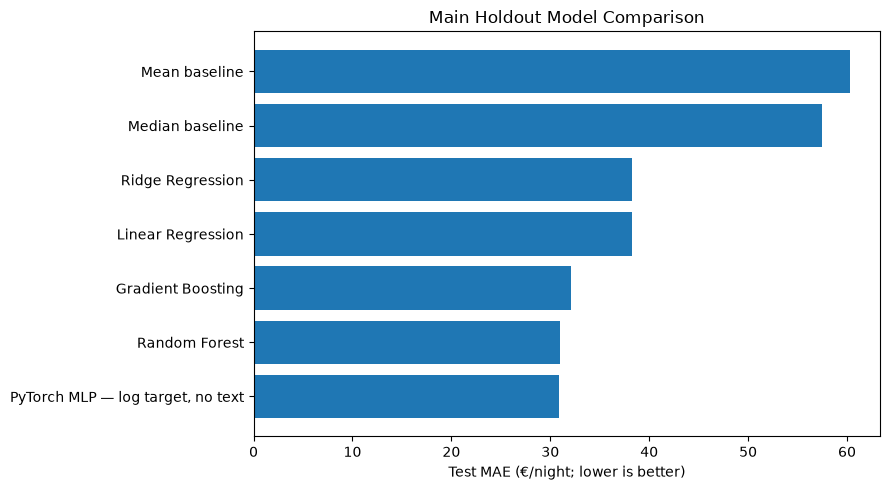

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = model_comparison.sort_values("test_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["test_mae"])
ax.set_xlabel("Test MAE (€/night; lower is better)")
ax.set_title("Main Holdout Model Comparison")
fig.tight_layout()
plt.show()

### MLP optimization history

The training curve shows the Huber objective on mini-batches and the early-stopping MAE in euros. The best epoch is restored before holdout evaluation.

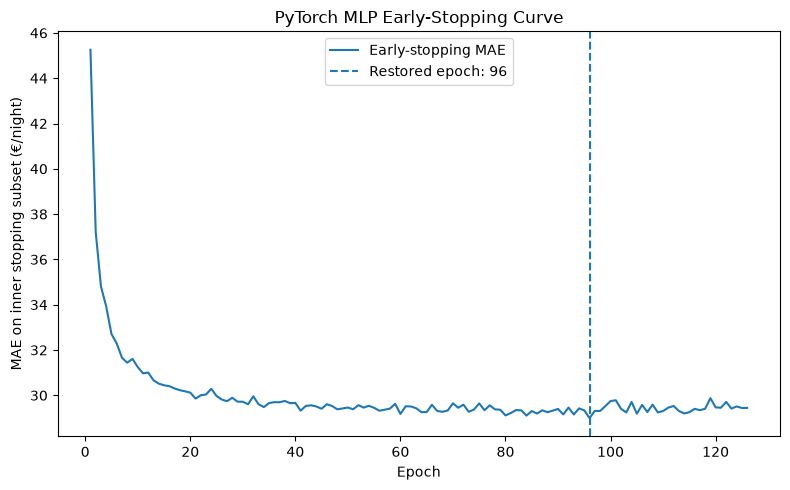

Best stopping-subset MAE: 28.994710346356154
Selected epoch: 96


In [16]:
mlp_history = mlp_main_artifacts["history"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mlp_history["epoch"], mlp_history["stopping_mae"], label="Early-stopping MAE")
ax.axvline(
    mlp_main_artifacts["best_epoch"],
    linestyle="--",
    label=f"Restored epoch: {mlp_main_artifacts['best_epoch']}",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE on inner stopping subset (€/night)")
ax.set_title("PyTorch MLP Early-Stopping Curve")
ax.legend()
fig.tight_layout()
plt.show()

print("Best stopping-subset MAE:", mlp_main_artifacts["best_stopping_mae"])
print("Selected epoch:", mlp_main_artifacts["best_epoch"])

## 8. Stability across random train/test splits

Five predetermined seeds are used with the selected hyperparameters fixed. This is a sensitivity analysis, not a second hyperparameter search. A model difference smaller than seed-to-seed variation should not be described as decisive.

In [17]:
def repeated_holdout_results(models, feature_columns, seeds=STABILITY_SEEDS):
    rows = []
    X_full = df[feature_columns]
    y_full = df[TARGET]
    bins_full = pd.qcut(y_full, q=10, duplicates="drop", labels=False)

    for seed in seeds:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_full, y_full,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=bins_full,
        )
        for name, estimator in models.items():
            fitted = clone(estimator).fit(X_tr, y_tr)
            pred = fitted.predict(X_te)
            rows.append({"seed": seed, "model": name, **regression_metrics(y_te, pred)})
    return pd.DataFrame(rows)

stability_models = {
    "Median baseline": median_baseline,
    "Mean baseline": mean_baseline,
    "Linear Regression": linear_model,
    "Ridge Regression": best_ridge,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gbr,
}
stability_runs = repeated_holdout_results(stability_models, all_predictors)
mlp_stability_rows = []
X_mlp_full = df[mlp_features]
y_full = df[TARGET]
bins_full = pd.qcut(y_full, q=10, duplicates="drop", labels=False)

for seed in STABILITY_SEEDS:
    train_indices, test_indices = train_test_split(
        np.arange(len(df)),
        test_size=TEST_SIZE,
        random_state=seed,
        stratify=bins_full,
    )
    artifacts = train_torch_mlp(
        X_mlp_full.iloc[train_indices],
        y_full.iloc[train_indices],
        X_mlp_full.iloc[test_indices],
        config=selected_mlp_config,
        seed=seed,
        max_epochs=300,
        patience=30,
    )
    mlp_stability_rows.append({
        "seed": seed,
        "model": "PyTorch MLP — log target, no text",
        **regression_metrics(
            y_full.iloc[test_indices], artifacts["evaluation_prediction"]
        ),
    })

mlp_stability_runs = pd.DataFrame(mlp_stability_rows)
stability_runs = pd.concat([stability_runs, mlp_stability_runs], ignore_index=True)

stability_summary = (
    stability_runs.groupby("model")
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        sd_r2=("r2", "std"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .sort_values("mean_mae")
    .reset_index()
)
display(stability_summary)

,model,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,sd_r2,mean_within_25,mean_within_50
0,"PyTorch MLP — log target, no text",30.342,0.543,48.298,1.170,0.647,0.020,0.607,0.830
1,Random Forest,30.508,0.529,47.701,1.062,0.656,0.012,0.591,0.834
2,Gradient Boosting,31.758,0.612,50.151,1.291,0.620,0.006,0.571,0.828
3,Linear Regression,38.163,0.553,55.123,1.051,0.541,0.013,0.447,0.751
4,Ridge Regression,38.187,0.548,55.145,1.056,0.541,0.013,0.447,0.750
5,Median baseline,57.157,0.813,84.584,2.447,-0.080,0.001,0.323,0.617
6,Mean baseline,59.971,0.735,81.394,2.334,-0.000,0.000,0.239,0.507


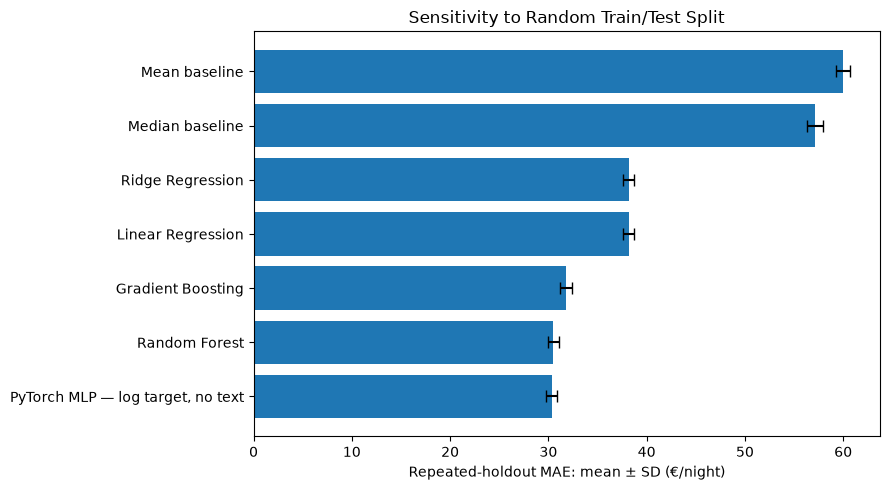

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = stability_summary.sort_values("mean_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["mean_mae"], xerr=plot_data["sd_mae"], capsize=4)
ax.set_xlabel("Repeated-holdout MAE: mean ± SD (€/night)")
ax.set_title("Sensitivity to Random Train/Test Split")
fig.tight_layout()
plt.show()

## 9. Spatial-feature ablation

Three location settings are compared:

1. **No spatial information:** no coordinates, distance, or borough indicators.
2. **Coarse location:** borough indicators only.
3. **Full spatial information:** borough indicators, coordinates, and distance to the centre.

The same selected estimators and seeds are used so that location is the controlled change.

In [19]:
ablation_models = {
    "Ridge Regression": best_ridge,
    "Random Forest — log target": TransformedTargetRegressor(
        regressor=clone(best_rf),
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    ),
}

# The final Random Forest candidate excludes simple text features. Its spatial
# ablation therefore keeps text excluded in all three location settings.
spatial_features_by_model = {
    "Ridge Regression": {
        "no_spatial": feature_sets["no_spatial"],
        "coarse_location": feature_sets["coarse_location"],
        "full_spatial": all_predictors,
    },
    "Random Forest — log target": {
        "no_spatial": tabular_features,
        "coarse_location": tabular_features + coarse_spatial_features,
        "full_spatial": feature_sets["without_text"],
    },
}

spatial_rows = []
for model_name, estimator in ablation_models.items():
    for setting, columns in spatial_features_by_model[model_name].items():
        result = repeated_holdout_results({model_name: estimator}, columns)
        result["spatial_setting"] = setting
        spatial_rows.append(result)

spatial_runs = pd.concat(spatial_rows, ignore_index=True)
spatial_ablation = (
    spatial_runs.groupby(["model", "spatial_setting"])
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .reset_index()
)
display(spatial_ablation.sort_values(["model", "mean_mae"]))

,model,spatial_setting,mean_mae,sd_mae,mean_rmse,mean_r2,mean_within_25,mean_within_50
1,Random Forest — log target,full_spatial,29.288,0.392,48.593,0.643,0.629,0.845
0,Random Forest — log target,coarse_location,30.853,0.694,50.168,0.620,0.611,0.827
2,Random Forest — log target,no_spatial,31.317,0.652,50.513,0.615,0.599,0.824
4,Ridge Regression,full_spatial,38.187,0.548,55.145,0.541,0.447,0.750
3,Ridge Regression,coarse_location,38.730,0.545,55.871,0.528,0.443,0.743
5,Ridge Regression,no_spatial,39.456,0.514,56.924,0.510,0.444,0.739


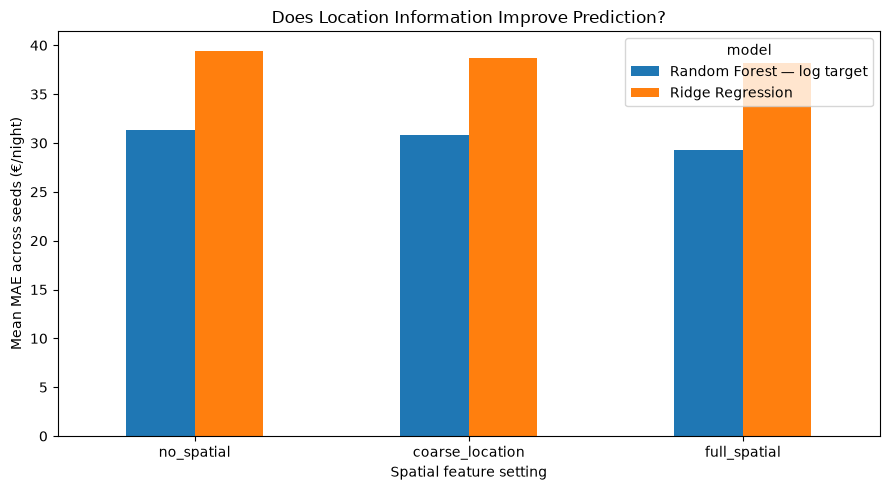

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = spatial_ablation.pivot(index="spatial_setting", columns="model", values="mean_mae")
pivot.loc[["no_spatial", "coarse_location", "full_spatial"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_xlabel("Spatial feature setting")
ax.set_title("Does Location Information Improve Prediction?")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

## 10. Text-feature ablation

The current text modality contains only length and word-count features. The ablation compares Ridge and a log-target Random Forest with and without these six summaries. It tests this specific representation, not the value of semantic text in general.

In [21]:
text_rows = []
for setting, columns in {
    "without_text": feature_sets["without_text"],
    "with_text": all_predictors,
}.items():
    result = repeated_holdout_results(ablation_models, columns)
    result["text_setting"] = setting
    text_rows.append(result)

text_runs = pd.concat(text_rows, ignore_index=True)
text_ablation = (
    text_runs.groupby(["model", "text_setting"])
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean"),
    )
    .reset_index()
)
display(text_ablation.sort_values(["model", "mean_mae"]))

,model,text_setting,mean_mae,sd_mae,mean_rmse,mean_r2
1,Random Forest — log target,without_text,29.288,0.392,48.593,0.643
0,Random Forest — log target,with_text,29.310,0.437,48.699,0.642
2,Ridge Regression,with_text,38.187,0.548,55.145,0.541
3,Ridge Regression,without_text,38.402,0.606,55.411,0.536


## 11. Loss-function stability

The loss-only Gradient Boosting comparison is repeated over the same five seeds. The evaluation metrics remain MAE, RMSE, and R² in euros regardless of the internal training loss.

In [22]:
loss_models = {
    loss: GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        loss=loss,
        **best_gbr_structure,
    )
    for loss in ["squared_error", "absolute_error", "huber"]
}
loss_runs = repeated_holdout_results(loss_models, all_predictors)
loss_comparison = (
    loss_runs.groupby("model")
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .sort_values("mean_mae")
    .reset_index()
    .rename(columns={"model": "loss"})
)
display(loss_comparison)

,loss,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50
0,huber,31.758,0.612,50.151,1.291,0.620,0.571,0.828
1,squared_error,32.138,0.617,48.825,1.011,0.640,0.553,0.816
2,absolute_error,32.175,0.570,52.214,1.360,0.588,0.589,0.820


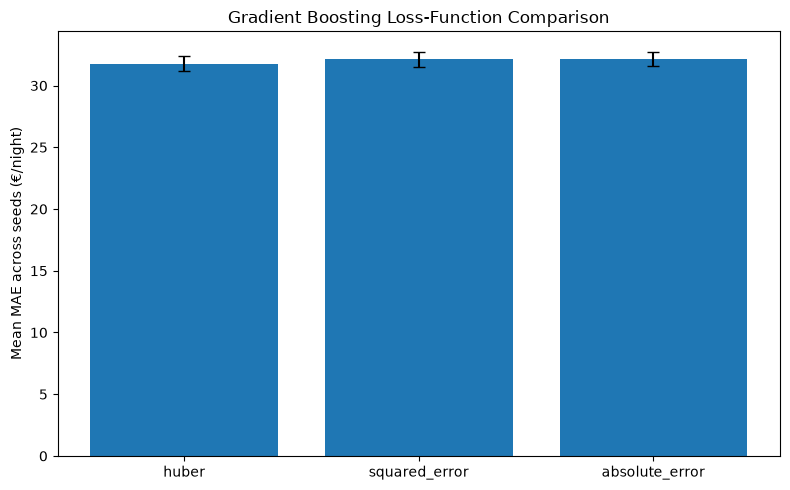

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(loss_comparison["loss"], loss_comparison["mean_mae"], yerr=loss_comparison["sd_mae"], capsize=4)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_title("Gradient Boosting Loss-Function Comparison")
fig.tight_layout()
plt.show()

## 12. Final-candidate and target-scale sensitivity

Because price is right-skewed, the strongest model families are compared on both the raw target and `log(1 + price)`. The log transform changes the error preference: it usually improves typical euro error but can underpredict expensive listings and therefore worsen RMSE. The decision is made using the same training cross-validation splits, not the held-out test set.

The Random Forest is also compared with and without the six simple text-length features. This allows the data to determine whether the current text representation is useful instead of forcing every modality into the final model.

In [24]:
raw_rf = clone(best_rf)
log_rf = TransformedTargetRegressor(
    regressor=clone(best_rf),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)
raw_ridge = clone(best_ridge)
log_ridge = TransformedTargetRegressor(
    regressor=clone(best_ridge),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)

final_candidate_definitions = {
    "Random Forest — raw target, full features": {
        "estimator": raw_rf,
        "features": all_predictors,
        "target_scale": "raw_price",
        "text_setting": "with_text",
    },
    "Random Forest — log target, full features": {
        "estimator": log_rf,
        "features": all_predictors,
        "target_scale": "log1p_price",
        "text_setting": "with_text",
    },
    "Random Forest — raw target, no text": {
        "estimator": clone(best_rf),
        "features": feature_sets["without_text"],
        "target_scale": "raw_price",
        "text_setting": "without_text",
    },
    "Random Forest — log target, no text": {
        "estimator": TransformedTargetRegressor(
            regressor=clone(best_rf),
            func=np.log1p,
            inverse_func=np.expm1,
            check_inverse=False,
        ),
        "features": feature_sets["without_text"],
        "target_scale": "log1p_price",
        "text_setting": "without_text",
    },
    "Gradient Boosting — selected loss, full features": {
        "estimator": clone(best_gbr),
        "features": all_predictors,
        "target_scale": "raw_price",
        "text_setting": "with_text",
    },
    "Ridge — raw target, full features": {
        "estimator": raw_ridge,
        "features": all_predictors,
        "target_scale": "raw_price",
        "text_setting": "with_text",
    },
    "Ridge — log target, full features": {
        "estimator": log_ridge,
        "features": all_predictors,
        "target_scale": "log1p_price",
        "text_setting": "with_text",
    },
}

candidate_cv_rows = []
for candidate_name, spec in final_candidate_definitions.items():
    result = cross_validate(
        spec["estimator"],
        X_train[spec["features"]],
        y_train,
        cv=cv_splits,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
        return_train_score=True,
    )
    candidate_cv_rows.append({
        "candidate": candidate_name,
        "target_scale": spec["target_scale"],
        "text_setting": spec["text_setting"],
        "mean_cv_mae": -result["test_mae"].mean(),
        "sd_cv_mae": result["test_mae"].std(ddof=1),
        "mean_cv_rmse": -result["test_rmse"].mean(),
        "mean_cv_r2": result["test_r2"].mean(),
        "mean_train_mae": -result["train_mae"].mean(),
    })

candidate_cv_rows.append({
    "candidate": "PyTorch MLP — log target, no text",
    "target_scale": "log1p_price",
    "text_setting": "without_text",
    "mean_cv_mae": mlp_cv_summary.loc[0, "mean_cv_mae"],
    "sd_cv_mae": mlp_cv_summary.loc[0, "sd_cv_mae"],
    "mean_cv_rmse": mlp_cv_summary.loc[0, "mean_cv_rmse"],
    "mean_cv_r2": mlp_cv_summary.loc[0, "mean_cv_r2"],
    "mean_train_mae": np.nan,
})

final_candidate_cv = (
    pd.DataFrame(candidate_cv_rows)
    .sort_values("mean_cv_mae")
    .reset_index(drop=True)
)
display(final_candidate_cv)

selected_candidate_name = final_candidate_cv.loc[0, "candidate"]
if selected_candidate_name == "PyTorch MLP — log target, no text":
    selected_candidate = {
        "features": mlp_features,
        "target_scale": "log1p_price",
        "text_setting": "without_text",
        "estimator": None,
    }
else:
    selected_candidate = final_candidate_definitions[selected_candidate_name]
print("Selected by lowest training cross-validated MAE:", selected_candidate_name)

# Repeated holdout is used only as a robustness check after selection.
candidate_stability_rows = []
y_full = df[TARGET]
bins_full = pd.qcut(y_full, q=10, duplicates="drop", labels=False)
for seed in STABILITY_SEEDS:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=TEST_SIZE,
        random_state=seed,
        stratify=bins_full,
    )
    for candidate_name, spec in final_candidate_definitions.items():
        features = spec["features"]
        estimator = clone(spec["estimator"])
        estimator.fit(df.iloc[train_idx][features], y_full.iloc[train_idx])
        pred = estimator.predict(df.iloc[test_idx][features])
        candidate_stability_rows.append({
            "seed": seed,
            "candidate": candidate_name,
            **regression_metrics(y_full.iloc[test_idx], pred),
        })

final_candidate_stability_runs = pd.DataFrame(candidate_stability_rows)
mlp_candidate_stability = mlp_stability_runs.rename(
    columns={"model": "candidate"}
)
final_candidate_stability_runs = pd.concat(
    [final_candidate_stability_runs, mlp_candidate_stability],
    ignore_index=True,
)
final_candidate_stability = (
    final_candidate_stability_runs.groupby("candidate")
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .sort_values("mean_mae")
    .reset_index()
)
display(final_candidate_stability)

,candidate,target_scale,text_setting,mean_cv_mae,sd_cv_mae,mean_cv_rmse,mean_cv_r2,mean_train_mae
0,"Random Forest — log target, no text",log1p_price,without_text,30.330,0.512,49.719,0.622,13.667
1,"Random Forest — log target, full features",log1p_price,with_text,30.395,0.489,49.890,0.620,13.518
2,"PyTorch MLP — log target, no text",log1p_price,without_text,31.238,0.400,50.814,0.605,NaN
3,"Random Forest — raw target, no text",raw_price,without_text,31.530,0.506,48.946,0.634,13.853
4,"Random Forest — raw target, full features",raw_price,with_text,31.716,0.330,49.123,0.631,13.668
5,"Gradient Boosting — selected loss, full features",raw_price,with_text,32.283,0.399,50.703,0.607,29.752
6,"Ridge — log target, full features",log1p_price,with_text,37.039,0.228,58.767,0.472,36.547
7,"Ridge — raw target, full features",raw_price,with_text,38.592,0.487,56.253,0.516,38.001


Selected by lowest training cross-validated MAE: Random Forest — log target, no text


,candidate,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50
0,"Random Forest — log target, no text",29.288,0.392,48.593,1.093,0.643,0.629,0.845
1,"Random Forest — log target, full features",29.310,0.437,48.699,1.154,0.642,0.634,0.846
2,"PyTorch MLP — log target, no text",30.342,0.543,48.298,1.170,0.647,0.607,0.830
3,"Random Forest — raw target, no text",30.403,0.607,47.513,1.076,0.659,0.591,0.833
4,"Random Forest — raw target, full features",30.508,0.529,47.701,1.062,0.656,0.591,0.834
5,"Gradient Boosting — selected loss, full features",31.758,0.612,50.151,1.291,0.620,0.571,0.828
6,"Ridge — log target, full features",36.782,0.696,57.694,1.733,0.497,0.517,0.786
7,"Ridge — raw target, full features",38.187,0.548,55.145,1.056,0.541,0.447,0.750


## 13. Final-model diagnostics

The final candidate is selected by the primary metric, cross-validated MAE, using training data only. RMSE and R² are treated as important trade-offs rather than silently ignored. The fixed main test set is evaluated once after this selection.

,model,train_mae,test_mae,test_rmse,test_r2,test_median_absolute_error,test_within_25_eur,test_within_50_eur,test_negative_predictions
0,"Random Forest — log target, no text",13.258,29.421,49.076,0.647,17.651,0.640,0.849,0
1,"PyTorch MLP — log target, no text",24.100,30.901,50.240,0.630,18.653,0.614,0.824,0
2,Random Forest,13.188,30.991,48.309,0.658,20.519,0.582,0.832,0
3,Gradient Boosting,30.367,32.122,50.891,0.621,21.441,0.569,0.824,0
4,Linear Regression,38.053,38.247,55.546,0.548,28.126,0.448,0.754,7
5,Ridge Regression,38.070,38.286,55.578,0.547,28.059,0.449,0.753,6
6,Median baseline,56.843,57.450,85.866,-0.080,40.000,0.325,0.619,0
7,Mean baseline,59.659,60.316,82.621,-0.000,49.288,0.241,0.506,0


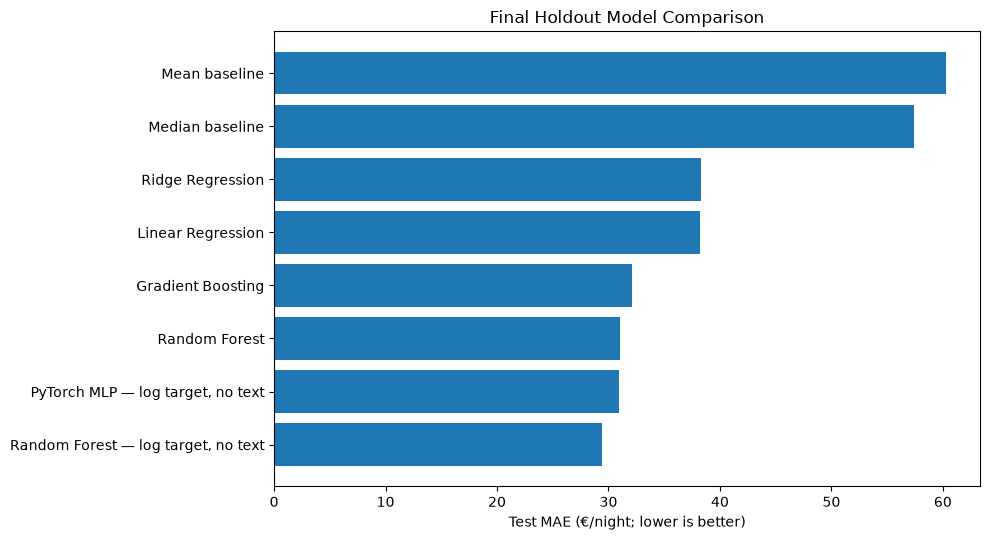

Final model selected from training CV: Random Forest — log target, no text
Main test metrics: {'mae': 29.420758269871794, 'rmse': 49.07648719370005, 'r2': 0.647145689070473, 'median_absolute_error': 17.650688889826085, 'within_10_eur': 0.3128065395095368, 'within_25_eur': 0.6403269754768393, 'within_50_eur': 0.8490463215258856, 'negative_predictions': 0}


In [25]:
final_features = selected_candidate["features"]
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

if selected_candidate_name == "PyTorch MLP — log target, no text":
    final_model = mlp_main_artifacts
    final_train_pred = mlp_train_prediction
    final_pred = mlp_test_prediction
    final_row = mlp_main_row
else:
    final_model, final_train_pred, final_pred, final_row = fit_and_evaluate(
        selected_candidate_name,
        selected_candidate["estimator"],
        X_train_final,
        y_train,
        X_test_final,
        y_test,
    )
final_abs_error = np.abs(y_test.to_numpy() - final_pred)
final_model_name = selected_candidate_name

# Add the selected candidate to the main table unless it is already represented exactly.
model_comparison_final = pd.concat(
    [model_comparison, pd.DataFrame([final_row])],
    ignore_index=True,
).drop_duplicates(subset=["model"], keep="last")
model_comparison_final = model_comparison_final.sort_values("test_mae").reset_index(drop=True)

display(model_comparison_final[[
    "model", "train_mae", "test_mae", "test_rmse", "test_r2",
    "test_median_absolute_error", "test_within_25_eur", "test_within_50_eur",
    "test_negative_predictions"
]])

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_data = model_comparison_final.sort_values("test_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["test_mae"])
ax.set_xlabel("Test MAE (€/night; lower is better)")
ax.set_title("Final Holdout Model Comparison")
fig.tight_layout()
plt.show()

print("Final model selected from training CV:", final_model_name)
print("Main test metrics:", regression_metrics(y_test, final_pred))

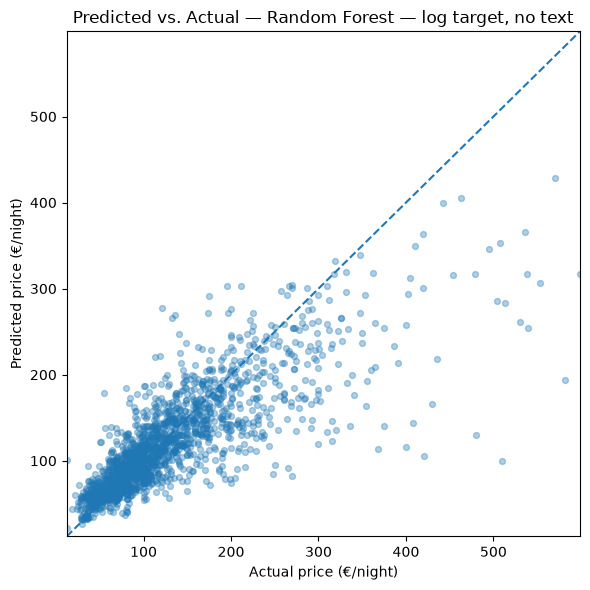

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, final_pred, alpha=0.35, s=18)
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual price (€/night)")
ax.set_ylabel("Predicted price (€/night)")
ax.set_title(f"Predicted vs. Actual — {final_model_name}")
fig.tight_layout()
plt.show()

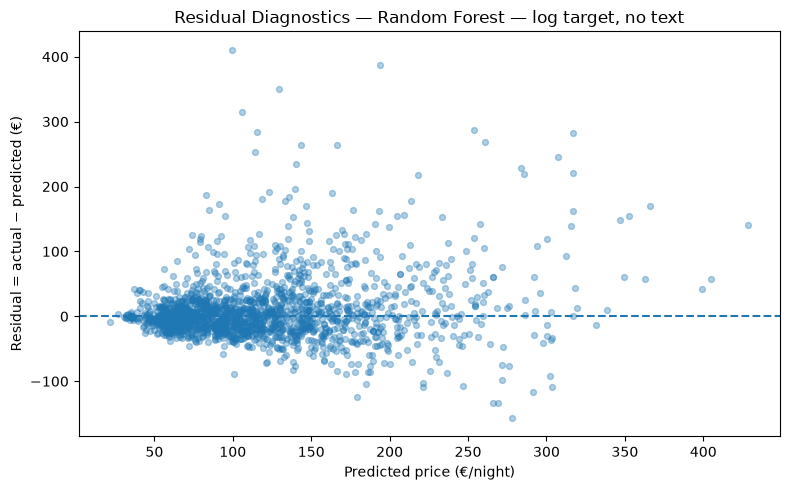

In [27]:
residuals = y_test.to_numpy() - final_pred
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(final_pred, residuals, alpha=0.35, s=18)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted price (€/night)")
ax.set_ylabel("Residual = actual − predicted (€)")
ax.set_title(f"Residual Diagnostics — {final_model_name}")
fig.tight_layout()
plt.show()

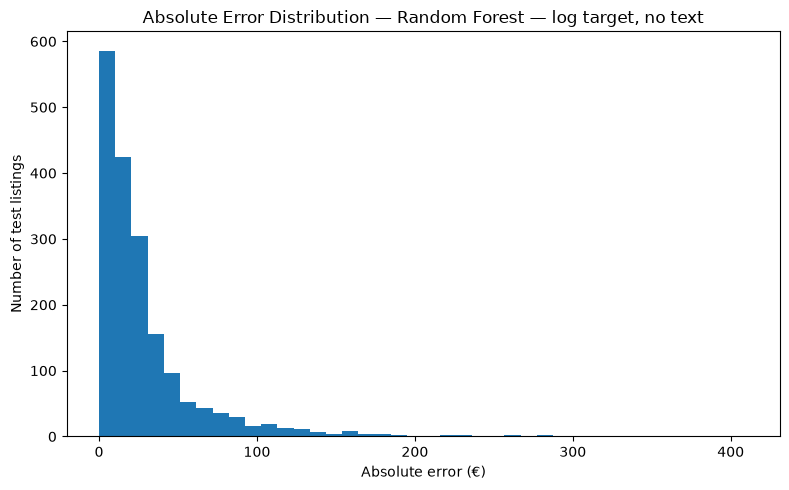

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(final_abs_error, bins=40)
ax.set_xlabel("Absolute error (€)")
ax.set_ylabel("Number of test listings")
ax.set_title(f"Absolute Error Distribution — {final_model_name}")
fig.tight_layout()
plt.show()

### Error by price band and room type

A €50 error is proportionally much more serious for a €70 listing than for a €500 listing. The following subgroup analysis therefore complements the global metrics. It is descriptive and should not be interpreted causally.

In [29]:
def reconstruct_room_type(frame):
    conditions = [
        frame["room_type_Hotel room"].eq(1),
        frame["room_type_Private room"].eq(1),
        frame["room_type_Shared room"].eq(1),
    ]
    choices = ["Hotel room", "Private room", "Shared room"]
    return np.select(conditions, choices, default="Entire home/apt")

error_frame = pd.DataFrame({
    "actual_price": y_test.to_numpy(),
    "predicted_price": final_pred,
    "absolute_error": final_abs_error,
    "room_type": reconstruct_room_type(X_test),
})
error_frame["price_quartile"] = pd.qcut(
    error_frame["actual_price"], q=4,
    labels=["Q1: lowest", "Q2", "Q3", "Q4: highest"],
    duplicates="drop",
)

price_band_errors = (
    error_frame.groupby("price_quartile", observed=False)
    .agg(
        n=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        median_ae=("absolute_error", "median"),
        within_25=("absolute_error", lambda s: np.mean(s <= 25)),
        within_50=("absolute_error", lambda s: np.mean(s <= 50)),
    )
    .reset_index()
)
room_type_errors = (
    error_frame.groupby("room_type")
    .agg(
        n=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        median_ae=("absolute_error", "median"),
        within_25=("absolute_error", lambda s: np.mean(s <= 25)),
        within_50=("absolute_error", lambda s: np.mean(s <= 50)),
    )
    .reset_index()
)

display(price_band_errors)
display(room_type_errors)

,price_quartile,n,mae,median_ae,within_25,within_50
0,Q1: lowest,481,14.548,10.950,0.813,0.977
1,Q2,437,18.004,14.077,0.773,0.957
2,Q3,459,23.528,19.213,0.649,0.915
3,Q4: highest,458,61.839,43.166,0.323,0.546


,room_type,n,mae,median_ae,within_25,within_50
0,Entire home/apt,1320,33.509,21.462,0.585,0.819
1,Hotel room,18,45.252,20.915,0.556,0.611
2,Private room,478,18.383,11.705,0.785,0.935
3,Shared room,19,8.073,6.713,0.947,1.000


### Permutation importance

Permutation importance measures the increase in test-set MAE when a feature is shuffled. It is more directly tied to predictive performance than impurity-based Random Forest importance, although correlated predictors can divide importance among themselves.

,feature,importance_mean,importance_sd
0,minimum_nights,12.898,0.665
1,accommodates,9.701,0.385
2,room_type_Private room,6.296,0.363
3,bedrooms,6.211,0.460
4,distance_to_center_km,3.777,0.261
5,bathrooms_parsed,2.800,0.204
6,host_listings_count,2.128,0.086
7,room_type_Shared room,1.219,0.098
8,instant_bookable,1.187,0.108
9,availability_60,0.986,0.098


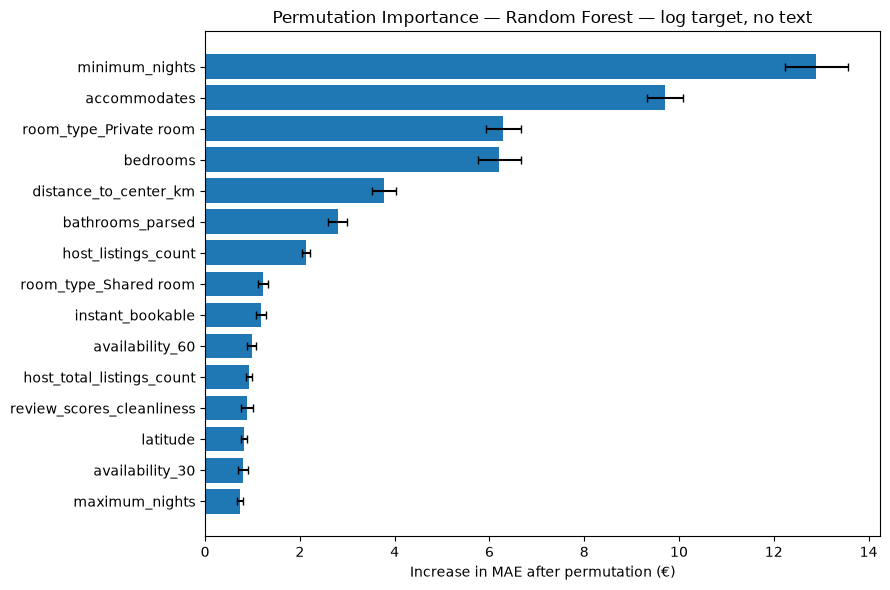

In [30]:
if final_model_name == "PyTorch MLP — log target, no text":
    rng = np.random.default_rng(RANDOM_STATE)
    baseline_mae = mean_absolute_error(y_test, final_pred)
    importance_rows = []
    for feature in X_test_final.columns:
        increases = []
        for _ in range(10):
            permuted = X_test_final.copy()
            permuted[feature] = rng.permutation(permuted[feature].to_numpy())
            prediction = predict_torch_mlp(final_model, permuted)
            increases.append(mean_absolute_error(y_test, prediction) - baseline_mae)
        importance_rows.append({
            "feature": feature,
            "importance_mean": np.mean(increases),
            "importance_sd": np.std(increases, ddof=1),
        })
    feature_importance = (
        pd.DataFrame(importance_rows)
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )
else:
    perm = permutation_importance(
        final_model,
        X_test_final,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    feature_importance = (
        pd.DataFrame({
            "feature": X_test_final.columns,
            "importance_mean": perm.importances_mean,
            "importance_sd": perm.importances_std,
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

display(feature_importance.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top = feature_importance.head(15).sort_values("importance_mean")
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_sd"], capsize=3)
ax.set_xlabel("Increase in MAE after permutation (€)")
ax.set_title(f"Permutation Importance — {final_model_name}")
fig.tight_layout()
plt.show()

### Gradient Boosting staged errors

These curves show how training and test MAE change as boosting stages are added. They are external MAE values, not incomparable internal objectives.

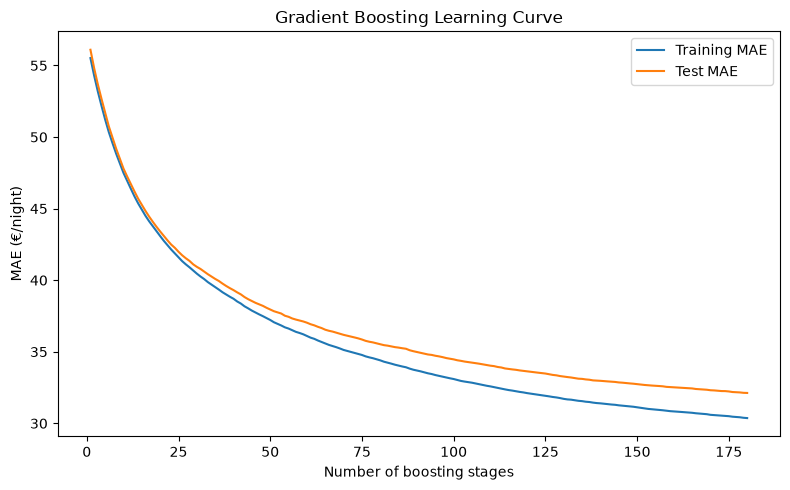

In [31]:
gbr_for_curve = fitted_models["Gradient Boosting"]
train_stage_mae = [mean_absolute_error(y_train, p) for p in gbr_for_curve.staged_predict(X_train)]
test_stage_mae = [mean_absolute_error(y_test, p) for p in gbr_for_curve.staged_predict(X_test)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(train_stage_mae) + 1), train_stage_mae, label="Training MAE")
ax.plot(range(1, len(test_stage_mae) + 1), test_stage_mae, label="Test MAE")
ax.set_xlabel("Number of boosting stages")
ax.set_ylabel("MAE (€/night)")
ax.set_title("Gradient Boosting Learning Curve")
ax.legend()
fig.tight_layout()
plt.show()

### Bootstrap uncertainty for the final holdout predictions

The interval below resamples the fixed test-set prediction pairs. It quantifies sampling uncertainty for this test set but does not capture dataset shift, preprocessing leakage, or uncertainty from changing the entire training sample.

In [32]:
def bootstrap_ci(y_true, y_pred, metric, n_boot=2000, confidence=0.95, seed=RANDOM_STATE):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.default_rng(seed)
    values = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        values.append(metric(y_true[idx], y_pred[idx]))
    alpha = 1 - confidence
    return np.quantile(values, [alpha / 2, 1 - alpha / 2])

mae_ci = bootstrap_ci(y_test, final_pred, mean_absolute_error)
rmse_ci = bootstrap_ci(y_test, final_pred, lambda a, b: mean_squared_error(a, b) ** 0.5)
bootstrap_intervals = pd.DataFrame({
    "metric": ["MAE", "RMSE"],
    "estimate": [mean_absolute_error(y_test, final_pred), mean_squared_error(y_test, final_pred) ** 0.5],
    "ci_2.5%": [mae_ci[0], rmse_ci[0]],
    "ci_97.5%": [mae_ci[1], rmse_ci[1]],
})
display(bootstrap_intervals)

,metric,estimate,ci_2.5%,ci_97.5%
0,MAE,29.421,27.722,31.270
1,RMSE,49.076,44.909,53.486


## 14. Reproducibility summary

All result tables and figures remain embedded in this executed notebook. No external output directory is required. The following cell records the selected configurations needed to reproduce the main comparison.

In [33]:
reproducibility_summary = pd.DataFrame({
    "item": [
        "Random state",
        "Holdout test fraction",
        "Repeated-holdout seeds",
        "Cross-validation folds",
        "Best Ridge alpha",
        "Best Random Forest parameters",
        "Best Gradient Boosting structure",
        "Best Gradient Boosting loss",
        "Selected MLP architecture",
        "Selected final candidate",
    ],
    "value": [
        RANDOM_STATE,
        TEST_SIZE,
        STABILITY_SEEDS,
        N_CV_SPLITS,
        ridge_search.best_params_["model__alpha"],
        rf_search.best_params_,
        best_gbr_structure,
        gbr_loss_search.best_params_["loss"],
        selected_mlp_architecture,
        selected_candidate_name,
    ],
})
display(reproducibility_summary)
print("All outputs are stored inside this notebook.")

,item,value
0,Random state,42
1,Holdout test fraction,0.200
2,Repeated-holdout seeds,"[0, 21, 42, 84, 123]"
3,Cross-validation folds,3
4,Best Ridge alpha,10.000
5,Best Random Forest parameters,"{'max_depth': None, 'max_features': 0.7, 'min_..."
6,Best Gradient Boosting structure,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s..."
7,Best Gradient Boosting loss,huber
8,Selected MLP architecture,PyTorch MLP 64-32
9,Selected final candidate,"Random Forest — log target, no text"


All outputs are stored inside this notebook.


## 15. Scientific interpretation and self-critique

### What the results can support

- Predictive comparisons among the tested models for listings drawn from approximately the same cleaned Berlin dataset distribution.
- Whether the current spatial and simple text features improve repeated-holdout prediction.
- Whether MAE-oriented, squared-error, or Huber Gradient Boosting is more stable under the tested configurations.
- Whether a compact, regularized PyTorch MLP is competitive with the classical tabular models under the same data split and primary metric.

### Important model and metric trade-offs

The log-target Random Forest is selected because MAE is the declared primary metric. It can have worse RMSE than the raw-target model because it underpredicts the highest-price quartile more strongly. The result is therefore a trade-off rather than universal dominance.

The PyTorch MLP is a useful neural-network benchmark, but it is not selected as the final model because its training cross-validated MAE is higher than the Random Forest's. Its inclusion shows that a neural model was tested under controlled preprocessing, regularization, early stopping, and repeated seeds rather than assumed to be better.

### What the results cannot support

- Causal claims about why a feature changes price.
- Generalization to other cities, future Airbnb markets, or the removed top 1% of prices.
- Claims about completely unseen hosts, because `host_id` was not retained for grouped validation.
- Semantic value of listing text, because only lengths and word counts were modeled.

### Weakest methodological choice

Preprocessing and outlier removal occurred before the train/test split in Parts 1 and 2. This modest optimistic leakage risk remains unresolved without rerunning preprocessing from raw data inside split-aware pipelines.

### Most likely implementation failure to guard against

Accidentally retaining `id`, or removing coordinates while leaving borough indicators and describing the experiment as “without location.” The explicit feature lists and assertions above guard against both errors.

### Strongest alternative explanation

Apparent gains from spatial variables may reflect correlated property types, room types, or host behavior concentrated in particular boroughs rather than a direct location effect. This is predictive association, not causation.

### Remaining practical uncertainty

A €50 error is not necessarily equally serious at every listing price. MAE, RMSE, threshold accuracy, price-quartile error analysis, and alternative losses expose this trade-off, but the project has no externally supplied business cost function that defines the exact economic value of each error size.